# Fig. 7A: sketch for keeping current beam aim or moving to a neighboring grid

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

from infotaxis import one_target
from infotaxis import hex_ops, utils
from infotaxis.utils_plot_hex import PLOT_ATTRS, get_echo_type_str, plot_dk_map, plot_entropy_seq

In [2]:
path_fig = Path("../figs")

In [3]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_loc_standalone(ax, axis_ij, sym='o', color='m', size=10):
    ax.plot(axis_ij[0], axis_ij[1],
            markersize=size,
            marker=sym,
            markerfacecolor="None",
            markeredgecolor=color,
            markeredgewidth=1.5)

In [4]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_dk_map_standalone(
    ax, canvas_cube, canvas_vmap,
    plot_attrs, cmap="Blues_r",
    remove_cbar=False
):
    im, cbar = hex_ops.plot_hexgrids(ax,
                                     cube_array=canvas_cube,
                                     cube_color=canvas_vmap,
                                     cmap=cmap)
    ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])
    ax.axis('equal')
    if remove_cbar:
        cbar.remove()
    else:
        pos = cbar.ax.get_position()
        cbar.ax.set_position([pos.x0 - 0.04, pos.y0, pos.width, pos.height])
        cbar.ax.set_yticks([])

In [5]:
# Move to a neighboring grid
param_echo_n = {
    str(1): {
        "pm_const": 0.001,
        "pfa_const": 0.001,
    },
}

oth_n = one_target.OneTargetHex(
    search_rule="infotaxis",  # search rule: "infotaxis", "MAP_future", "MAP"
    canvas_radius=5,
    beam_radius=[1],
    target_cube=(1, -2, 1),
    aim_start_cube=[0, 0, 0],
    param_animal= param_echo_n,
    param_echo= param_echo_n,
    search_dict=None
)

oth_n.echo_value = True
oth_n.update_X1()

# Update h after updating the map
oth_n.get_h_actual()
oth_n.get_est_ph()

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1


In [6]:
# Repeat current beam aim
param_echo_c = {
    str(1): {
        "pm_const": 0.02,
        "pfa_const": 0.02,
    },
}

oth_c = one_target.OneTargetHex(
    search_rule="infotaxis",  # search rule: "infotaxis", "MAP_future", "MAP"
    canvas_radius=5,
    beam_radius=[1],
    target_cube=(1, -2, 1),
    aim_start_cube=[0, 0, 0],
    param_animal= param_echo_c,
    param_echo= param_echo_c,
    search_dict=None
)

oth_c.echo_value = True
oth_c.update_X1()

# Update h after updating the map
oth_c.get_h_actual()
oth_c.get_est_ph()

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1


In [7]:
beam_cube = [0, 0, 0]
beam_plotxy = hex_ops.get_cube_plot_xy(beam_cube)

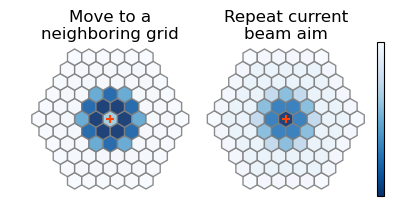

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(5.5, 2))
fig.subplots_adjust(wspace=-0.3)

plot_dk_map_standalone(
    ax[0],
    canvas_cube=oth_n.canvas_cube,
    canvas_vmap=oth_n.h_est[1],
    plot_attrs=PLOT_ATTRS,
    cmap="Blues_r",
    remove_cbar=True
)
plot_loc_standalone(  # plot last beam axis
    ax=ax[0],
    axis_ij=hex_ops.get_cube_plot_xy(beam_cube),
    sym='+',
    color=PLOT_ATTRS['symbol_color'],
    size=6
)
ax[0].set_title("Move to a\nneighboring grid", fontsize=12, pad=0)
ax[0].patch.set_visible(False)
ax[0].axis('off')

plot_dk_map_standalone(
    ax[1],
    canvas_cube=oth_c.canvas_cube,
    canvas_vmap=oth_c.h_est[1],
    plot_attrs=PLOT_ATTRS,
    cmap="Blues_r",
    remove_cbar=False
)
plot_loc_standalone(  # plot last beam axis
    ax=ax[1],
    axis_ij=hex_ops.get_cube_plot_xy(beam_cube),
    sym='+',
    color=PLOT_ATTRS['symbol_color'],
    size=6
)
ax[1].set_title("Repeat current\nbeam aim", fontsize=12, pad=0)
ax[1].patch.set_visible(False)
ax[1].axis('off')

plt.show()

fig.savefig(path_fig / "fig_7A_sketch_current_neighbor_beam_aim.png", dpi=300, bbox_inches="tight")